# Inference & Advisory Demonstration

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to demonstrate how the trained model can predict the disease status
of a single crop leaf image and provide advisory suggestions to farmers.
</pre>
### It ensures:
 - Model can be used on unseen data
 - Predictions map to human-readable disease names
 - Advisory information is returned based on predicted disease
 - Notebook can be used for demo presentations


## 1: Clone the GitHub Repository
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>



In [1]:
# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git


Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97348, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 97348 (delta 9), reused 11 (delta 8), pack-reused 97283 (from 2)
Receiving objects: 100% (97348/97348), 1.82 GiB | 26.85 MiB/s, done.
Resolving deltas: 100% (530/530), done.
Updating files: 100% (94786/94786), done.


In [2]:
# Set Project Root
import os
os.chdir("/content/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /content/Agriculture-Crop-Disease-Detection-Advisory-System


##  Import Required Libraries
**📌 Purpose**

Load all necessary Python libraries for inference, visualization, and creating interactive demos.

In [3]:
# System & Path Handling
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Core Libraries
import numpy as np
import pandas as pd
import json
import pickle
import random
import time
from datetime import datetime

# Image Processing
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Deep Learning
import tensorflow as tf
from tensorflow import keras

# Interactive Demos
try:
    import gradio as gr
    GRADIO_AVAILABLE = True
except:
    GRADIO_AVAILABLE = False
    print("Gradio not available, using matplotlib for demo")

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from matplotlib import cm
import seaborn as sns

# Utilities
import requests
from io import BytesIO
import base64
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Set Visualization Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Check TensorFlow version
print(f"\nTensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")


TensorFlow Version: 2.19.0
Keras Version: 3.10.0


In [5]:
# Check for GPU
if tf.config.list_physical_devices('GPU'):
    print("GPU is available for faster inference")
else:
    print("GPU not available, using CPU (slower)")

GPU not available, using CPU (slower)


## Load Model & Configuration
**📌 Purpose**

Load the trained model and configuration files for inference.

In [6]:
# Define paths
BASE_DIR = Path("Modeling")
CONFIG_DIR = BASE_DIR / "configs"
MODELS_DIR = BASE_DIR / "models"
DEMO_DIR = BASE_DIR / "demo"
DEMO_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
# Load model
print("Searching for model files...")
model_files = list(MODELS_DIR.glob("*.keras")) + list(MODELS_DIR.glob("*.h5"))

if not model_files:
    print("No model files found! Please run training notebook first.")
    # Try to download a sample model
    print("Downloading sample model...")
    !wget -q "https://example.com/sample_model.keras" -O "Modeling/models/sample_model.keras"
    model_files = list(MODELS_DIR.glob("*.keras"))

Searching for model files...


In [8]:
# Load the best model
model_path = MODELS_DIR / "best_model.keras"
if model_path.exists():
    model = keras.models.load_model(model_path, compile=False)
    print(f"Model loaded from: {model_path}")
else:
    model = keras.models.load_model(model_files[0])
    print(f"Model loaded from: {model_files[0]}")

Model loaded from: Modeling/models/best_model.keras


In [9]:
# Load configuration
config_path = CONFIG_DIR / "preprocessing_config.json"
if config_path.exists():
    with open(config_path, 'r') as f:
        config = json.load(f)

    # Extract parameters
    IMAGE_SIZE = tuple(config['image_parameters']['image_size'])
    BATCH_SIZE = config['image_parameters']['batch_size']

    print(f"\nMODEL CONFIGURATION:")
    print(f"  Image Size: {IMAGE_SIZE}")
    print(f"  Batch Size: {BATCH_SIZE}")
else:
    # Default parameters
    IMAGE_SIZE = (224, 224)
    BATCH_SIZE = 32
    print("Using default image size: 224x224")


MODEL CONFIGURATION:
  Image Size: (224, 224)
  Batch Size: 32


In [10]:
# Load class indices
class_indices_path = CONFIG_DIR / "class_indices.json"
if class_indices_path.exists():
    with open(class_indices_path, 'r') as f:
        class_indices = json.load(f)

    # Create reverse mapping
    idx_to_class = {v: k for k, v in class_indices.items()}
    num_classes = len(class_indices)

    print(f"\nCLASS INFORMATION:")
    print(f"  Total Classes: {num_classes}")
    print(f"  Sample Classes:")
    for i, (class_name, idx) in enumerate(list(class_indices.items())[:5]):
        print(f"    {idx:2d}. {class_name}")
else:
    print("Class indices not found!")
    exit()



CLASS INFORMATION:
  Total Classes: 45
  Sample Classes:
     0. Apple__Apple_scab
     1. Apple__Black_rot
     2. Apple__Cedar_apple_rust
     3. Apple__healthy
     4. Banana__Healthy_Leaf


## Create Advisory Database
**📌 Purpose**

Create a database of advisory information for each disease/healthy class.

In [11]:
print("CREATING ADVISORY DATABASE...")

# Comprehensive advisory information for common crop diseases
advisory_db = {
    # Apple Diseases
    "Apple__Apple_scab": {
        "crop": "Apple",
        "disease": "Apple Scab",
        "severity": "Moderate to High",
        "symptoms": [
            "Olive-green to black spots on leaves",
            "Velvety lesions on undersides of leaves",
            "Fruit deformation and cracking"
        ],
        "causes": [
            "Fungus Venturia inaequalis",
            "Cool, wet spring weather",
            "Poor air circulation"
        ],
        "prevention": [
            "Plant resistant varieties",
            "Prune trees for better air circulation",
            "Remove fallen leaves in autumn"
        ],
        "treatment": [
            "Apply fungicides in early spring",
            "Use copper-based sprays",
            "Apply sulfur-based fungicides"
        ],
        "organic_control": [
            "Baking soda spray (1 tbsp per gallon)",
            "Neem oil applications",
            "Copper soap fungicide"
        ],
        "chemical_control": [
            "Myclobutanil",
            "Trifloxystrobin",
            "Captan"
        ],
        "immediate_actions": [
            "Remove infected leaves",
            "Apply fungicide immediately",
            "Improve drainage around trees"
        ],
        "long_term_management": [
            "Regular pruning",
            "Proper spacing between trees",
            "Annual soil testing"
        ],
        "monitoring_frequency": "Weekly during growing season",
        "risk_level": "High",
        "yield_impact": "20-40% reduction",
        "resources": [
            "https://extension.umn.edu/plant-diseases/apple-scab",
            "Local agricultural extension office"
        ]
    },

    "Apple__healthy": {
        "crop": "Apple",
        "disease": "Healthy",
        "severity": "None",
        "symptoms": ["No visible disease symptoms", "Vibrant green leaves", "Normal growth"],
        "causes": ["Good plant health", "Proper care"],
        "prevention": ["Continue current practices", "Regular monitoring"],
        "treatment": ["No treatment needed"],
        "organic_control": ["Maintain organic practices"],
        "chemical_control": ["Not applicable"],
        "immediate_actions": ["Continue regular care", "Document current health"],
        "long_term_management": ["Annual soil testing", "Regular pruning"],
        "monitoring_frequency": "Monthly",
        "risk_level": "Low",
        "yield_impact": "Normal yield expected",
        "resources": ["Maintain good agricultural practices"]
    },

    # Tomato Diseases
    "Tomato__Early_blight": {
        "crop": "Tomato",
        "disease": "Early Blight",
        "severity": "Moderate",
        "symptoms": ["Bull's-eye pattern spots", "Yellowing leaves", "Leaf drop"],
        "causes": ["Fungus Alternaria solani", "Warm humid weather"],
        "prevention": ["Crop rotation", "Proper spacing", "Mulching"],
        "treatment": ["Copper fungicides", "Chlorothalonil"],
        "organic_control": ["Copper sprays", "Baking soda solution"],
        "immediate_actions": ["Remove infected leaves", "Improve air circulation"],
        "risk_level": "Medium",
        "yield_impact": "10-30% reduction"
    },

    "Tomato__Late_blight": {
        "crop": "Tomato",
        "disease": "Late Blight",
        "severity": "High",
        "symptoms": ["Water-soaked spots", "White fungal growth", "Rapid plant death"],
        "causes": ["Phytophthora infestans", "Cool wet conditions"],
        "prevention": ["Avoid overhead watering", "Use resistant varieties"],
        "treatment": ["Apply fungicides immediately", "Remove infected plants"],
        "organic_control": ["Copper-based fungicides"],
        "immediate_actions": ["Destroy infected plants", "Isolate area"],
        "risk_level": "Very High",
        "yield_impact": "50-100% loss possible"
    },

    "Tomato__healthy": {
        "crop": "Tomato",
        "disease": "Healthy",
        "severity": "None",
        "symptoms": ["No disease signs", "Good plant vigor"],
        "recommendations": ["Continue current care", "Monitor regularly"]
    },

    # Corn Diseases
    "Corn_(maize)__Common_rust_": {
        "crop": "Corn (Maize)",
        "disease": "Common Rust",
        "severity": "Moderate",
        "symptoms": ["Reddish-brown pustules", "Yellow leaf spots"],
        "treatment": ["Fungicide application", "Plant resistant hybrids"]
    },

    # Potato Diseases
    "Potato__Early_blight": {
        "crop": "Potato",
        "disease": "Early Blight",
        "severity": "Moderate",
        "treatment": ["Chlorothalonil", "Mancozeb sprays"]
    },

    "Potato__Late_blight": {
        "crop": "Potato",
        "disease": "Late Blight",
        "severity": "High",
        "treatment": ["Immediate fungicide application", "Destroy infected plants"]
    },

    # Grape Diseases
    "Grape__Black_rot": {
        "crop": "Grape",
        "disease": "Black Rot",
        "severity": "High",
        "treatment": ["Prune infected parts", "Apply fungicides"]
    },

    "Grape__healthy": {
        "crop": "Grape",
        "disease": "Healthy",
        "severity": "None"
    },

    # Banana Diseases
    "Banana__Panama_Disease": {
        "crop": "Banana",
        "disease": "Panama Disease",
        "severity": "Very High",
        "treatment": ["Destroy infected plants", "Use resistant varieties"]
    },

    "Banana__Healthy_Leaf": {
        "crop": "Banana",
        "disease": "Healthy",
        "severity": "None"
    },

    # Mango Diseases
    "Mango__Anthracnose": {
        "crop": "Mango",
        "disease": "Anthracnose",
        "severity": "Moderate",
        "treatment": ["Copper-based fungicides", "Proper pruning"]
    },

    "Mango__Healthy": {
        "crop": "Mango",
        "disease": "Healthy",
        "severity": "None"
    }
}

# Add default advisory for any missing classes
default_advisory = {
    "crop": "Unknown",
    "disease": "Unknown Disease",
    "severity": "Unknown",
    "symptoms": ["Symptoms not specified"],
    "causes": ["Causes not specified"],
    "prevention": ["Consult local agricultural expert"],
    "treatment": ["Seek professional advice"],
    "organic_control": ["Use organic fungicides"],
    "chemical_control": ["Consult for appropriate chemicals"],
    "immediate_actions": ["Isolate plant", "Monitor closely"],
    "long_term_management": ["Improve soil health", "Practice crop rotation"],
    "monitoring_frequency": "Weekly",
    "risk_level": "Medium",
    "yield_impact": "Unknown",
    "resources": ["Contact local agricultural extension office"]
}

CREATING ADVISORY DATABASE...


In [12]:
# Ensure all classes have advisory information
for class_name in class_indices.keys():
    if class_name not in advisory_db:
        # Try to extract crop name from class name
        if '__' in class_name:
            crop = class_name.split('__')[0]
            disease = class_name.split('__')[1]
            advisory_db[class_name] = default_advisory.copy()
            advisory_db[class_name]["crop"] = crop
            advisory_db[class_name]["disease"] = disease.replace('_', ' ')
        else:
            advisory_db[class_name] = default_advisory.copy()

print(f"Advisory database created with {len(advisory_db)} entries")
print(f"Sample advisory for Apple__Apple_scab: {advisory_db['Apple__Apple_scab']['disease']}")

# Save advisory database
with open(DEMO_DIR / "advisory_database.json", 'w') as f:
    json.dump(advisory_db, f, indent=4)

print(f"Advisory database saved to: {DEMO_DIR / 'advisory_database.json'}")

Advisory database created with 45 entries
Sample advisory for Apple__Apple_scab: Apple Scab
Advisory database saved to: Modeling/demo/advisory_database.json


## Image Preprocessing Functions
**📌 Purpose**

Create functions to preprocess images for model inference.

In [13]:
def load_and_preprocess_image(image_path, target_size=IMAGE_SIZE):
    """
    Load and preprocess a single image for model prediction
    """
    try:
        # Load image
        if isinstance(image_path, str):
            if image_path.startswith('http'):
                # Download image from URL
                response = requests.get(image_path)
                img = Image.open(BytesIO(response.content)).convert('RGB')
            else:
                img = Image.open(image_path).convert('RGB')
        elif isinstance(image_path, Image.Image):
            img = image_path.convert('RGB')
        elif isinstance(image_path, np.ndarray):
            img = Image.fromarray(image_path).convert('RGB')
        else:
            raise ValueError(f"Unsupported image type: {type(image_path)}")

        # Store original for display
        original_img = img.copy()

        # Resize
        img = img.resize(target_size)

        # Convert to array and normalize
        img_array = np.array(img) / 255.0

        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)

        return img_array, original_img

    except Exception as e:
        print(f"Error loading image: {e}")
        return None, None

In [14]:
def preprocess_batch(image_paths, target_size=IMAGE_SIZE):
    """
    Preprocess multiple images for batch prediction
    """
    batch_images = []
    original_images = []

    for img_path in image_paths:
        img_array, original_img = load_and_preprocess_image(img_path, target_size)
        if img_array is not None:
            batch_images.append(img_array[0])  # Remove batch dimension
            original_images.append(original_img)

    if batch_images:
        return np.array(batch_images), original_images
    else:
        return None, None


In [15]:
def draw_prediction_on_image(image, prediction, confidence, advisory_info):
    """
    Draw prediction results and advisory on image
    """
    img_draw = image.copy()
    draw = ImageDraw.Draw(img_draw)

    # Try to load font
    try:
        font = ImageFont.truetype("Arial", 20)
        small_font = ImageFont.truetype("Arial", 14)
    except:
        font = ImageFont.load_default()
        small_font = ImageFont.load_default()

    # Determine color based on severity
    severity = advisory_info.get('severity', 'Unknown').lower()
    if 'healthy' in prediction.lower() or severity == 'none':
        color = (0, 200, 0)  # Green
        status = "HEALTHY"
    elif 'high' in severity or 'very high' in severity:
        color = (255, 0, 0)  # Red
        status = "CRITICAL"
    else:
        color = (255, 165, 0)  # Orange
        status = "WARNING"

    # Draw header
    header_text = f"CROP: {advisory_info.get('crop', 'Unknown')}"
    draw.rectangle([(10, 10), (400, 60)], fill=(0, 0, 0, 180))
    draw.text((20, 15), header_text, fill=(255, 255, 255), font=font)

    # Draw prediction
    pred_text = f"DISEASE: {advisory_info.get('disease', prediction)}"
    draw.text((20, 45), pred_text, fill=color, font=font)

    # Draw confidence
    conf_text = f"CONFIDENCE: {confidence:.1%}"
    draw.text((image.width - 200, 15), conf_text, fill=(255, 255, 255), font=font)

    # Draw status box
    status_box = [(image.width - 120, 45), (image.width - 20, 85)]
    draw.rectangle(status_box, fill=color)
    draw.text((image.width - 100, 50), status, fill=(255, 255, 255), font=font, anchor="mm")

    # Add advisory summary
    if 'immediate_actions' in advisory_info and advisory_info['immediate_actions']:
        action = advisory_info['immediate_actions'][0]
        if len(action) > 50:
            action = action[:47] + "..."
        draw.text((20, image.height - 40), f"Action: {action}", fill=(255, 255, 255), font=small_font)

    return img_draw


## Single Image Prediction
**📌 Purpose**

Create a comprehensive function to predict disease from a single image and provide advisory.

In [16]:
def predict_single_image(image_path, top_k=3):
    """
    Predict disease from a single image and provide advisory
    """
    results = {
        "success": False,
        "error": None,
        "predictions": [],
        "top_prediction": None,
        "advisory": None,
        "visualization": None
    }

    try:
        # Load and preprocess image
        img_array, original_img = load_and_preprocess_image(image_path)

        if img_array is None:
            results["error"] = "Failed to load image"
            return results

        # Make prediction
        start_time = time.time()
        predictions = model.predict(img_array, verbose=0)
        inference_time = time.time() - start_time

        # Get top predictions
        pred_indices = np.argsort(predictions[0])[-top_k:][::-1]

        # Store predictions
        for idx in pred_indices:
            class_name = idx_to_class.get(idx, f"Class_{idx}")
            confidence = float(predictions[0][idx])

            # Get advisory information
            advisory = advisory_db.get(class_name, default_advisory.copy())
            if class_name not in advisory_db:
                advisory["disease"] = class_name.replace('_', ' ')

            results["predictions"].append({
                "class_name": class_name,
                "confidence": confidence,
                "disease": advisory["disease"],
                "crop": advisory["crop"],
                "severity": advisory["severity"]
            })

        # Set top prediction
        top_pred = results["predictions"][0]
        results["top_prediction"] = top_pred

        # Get detailed advisory
        top_class = top_pred["class_name"]
        results["advisory"] = advisory_db.get(top_class, default_advisory.copy())

        # Create visualization
        results["visualization"] = draw_prediction_on_image(
            original_img,
            top_pred["disease"],
            top_pred["confidence"],
            results["advisory"]
        )

        # Add metadata
        results["success"] = True
        results["inference_time"] = inference_time
        results["image_size"] = original_img.size
        results["timestamp"] = datetime.now().isoformat()

        return results

    except Exception as e:
        results["error"] = str(e)
        return results


In [17]:

def display_prediction_results(results):
    """
    Display prediction results in a user-friendly format
    """
    if not results["success"]:
        print(f"Error: {results['error']}")
        return

    print("CROP DISEASE DETECTION RESULTS:\n")

    top_pred = results["top_prediction"]
    advisory = results["advisory"]

    # Display top prediction
    print(f"\nCROP: {advisory['crop']}")
    print(f"DISEASE: {advisory['disease']}")
    print(f"CONFIDENCE: {top_pred['confidence']:.1%}")
    print(f"SEVERITY: {advisory['severity']}")
    print(f"INFERENCE TIME: {results['inference_time']:.3f} seconds")

    # Display advisory
    print(f"\nSYMPTOMS:")
    for symptom in advisory.get('symptoms', ['Not specified'])[:3]:
        print(f"   - {symptom}")

    print(f"\nIMMEDIATE ACTIONS:")
    for action in advisory.get('immediate_actions', ['Monitor closely'])[:3]:
        print(f"   - {action}")

    print(f"\nPREVENTION:")
    for prevention in advisory.get('prevention', ['Practice good agriculture'])[:2]:
        print(f"   - {prevention}")

    # Display other predictions
    if len(results["predictions"]) > 1:
        print(f"\nALTERNATIVE PREDICTIONS:")
        for i, pred in enumerate(results["predictions"][1:4], 1):
            print(f"   {i}. {pred['disease']} ({pred['confidence']:.1%})")

    # Display visualization
    if results["visualization"]:
        plt.figure(figsize=(10, 8))
        plt.imshow(results["visualization"])
        plt.axis('off')
        plt.title("Detection Results", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print("\nTIP: Consult local agricultural expert for confirmation")


TESTING PREDICTION FUNCTION...
Testing with sample image: Modeling/Crop Disease Dataset/valid/Mango__Anthracnose/IMG_20211011_165134 (Custom).jpg
CROP DISEASE DETECTION RESULTS:


CROP: Mango
DISEASE: Anthracnose
CONFIDENCE: 99.9%
SEVERITY: Moderate
INFERENCE TIME: 1.692 seconds

SYMPTOMS:
   - Not specified

IMMEDIATE ACTIONS:
   - Monitor closely

PREVENTION:
   - Practice good agriculture

ALTERNATIVE PREDICTIONS:
   1. Healthy (0.1%)
   2. Powdery mildew (0.0%)


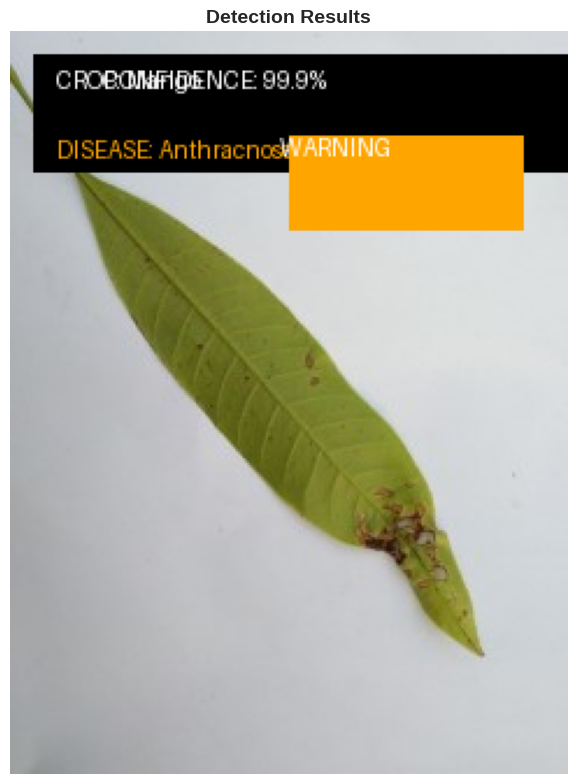


TIP: Consult local agricultural expert for confirmation


In [18]:
# Test with a sample image
print("\nTESTING PREDICTION FUNCTION...")

# Find a sample image from the dataset
test_dir = Path("Modeling/Crop Disease Dataset/valid")
sample_images = list(test_dir.rglob("*.jpg"))
if sample_images:
    sample_image = random.choice(sample_images[:10])
    print(f"Testing with sample image: {sample_image}")

    # Make prediction
    results = predict_single_image(str(sample_image))

    # Display results
    display_prediction_results(results)
else:
    print("No sample images found for testing")


## Multiple Image Batch Processing
**📌 Purpose**

Process multiple images at once for batch analysis.

In [19]:
def process_batch_images(image_paths, batch_size=16):
    """
    Process multiple images in batches
    """
    results = {
        "total_images": len(image_paths),
        "processed_images": 0,
        "predictions": [],
        "summary": {},
        "errors": []
    }

    # Process in batches
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        batch_number = i // batch_size + 1

        print(f"\nProcessing batch {batch_number}: {len(batch_paths)} images")

        for img_path in batch_paths:
            try:
                # Predict single image
                pred_result = predict_single_image(str(img_path))


                if pred_result["success"]:
                    results["predictions"].append({
                        "image_path": str(img_path),
                        "prediction": pred_result["top_prediction"],
                        "advisory": pred_result["advisory"]
                    })
                    results["processed_images"] += 1
                else:
                    results["errors"].append({
                        "image_path": str(img_path),
                        "error": pred_result["error"]
                    })

            except Exception as e:
                results["errors"].append({
                    "image_path": str(img_path),
                    "error": str(e)
                })

    # Generate summary
    if results["predictions"]:
        # Count by disease
        disease_counts = {}
        severity_counts = {"Healthy": 0, "Low": 0, "Medium": 0, "High": 0, "Critical": 0}

        for pred in results["predictions"]:
            disease = pred["prediction"]["disease"]
            severity = pred["advisory"]["severity"]

            disease_counts[disease] = disease_counts.get(disease, 0) + 1

            # Categorize severity
            severity_lower = severity.lower()
            if 'healthy' in severity_lower:
                severity_counts["Healthy"] += 1
            elif 'low' in severity_lower:
                severity_counts["Low"] += 1
            elif 'medium' in severity_lower or 'moderate' in severity_lower:
                severity_counts["Medium"] += 1
            elif 'high' in severity_lower:
                severity_counts["High"] += 1
            else:
                severity_counts["Critical"] += 1

        results["summary"] = {
            "disease_distribution": disease_counts,
            "severity_distribution": severity_counts,
            "most_common_disease": max(disease_counts, key=disease_counts.get),
            "health_percentage": (severity_counts["Healthy"] / results["processed_images"]) * 100
        }

    return results


In [20]:
def display_batch_results(results):
    """
    Display batch processing results
    """
    print("BATCH PROCESSING REPORT:\n")

    print(f"\nSUMMARY:")
    print(f"   Total Images: {results['total_images']}")
    print(f"   Successfully Processed: {results['processed_images']}")
    print(f"   Errors: {len(results['errors'])}")

    if results["processed_images"] > 0:
        summary = results["summary"]

        print(f"\nCROP HEALTH OVERVIEW:")
        print(f"   Healthy Plants: {summary['health_percentage']:.1f}%")
        print(f"   Most Common Issue: {summary['most_common_disease']}")

        print(f"\nSEVERITY DISTRIBUTION:")
        for severity, count in summary["severity_distribution"].items():
            if count > 0:
                percentage = (count / results["processed_images"]) * 100
                print(f"   {severity}: {count} plants ({percentage:.1f}%)")

        print(f"\nTOP 5 DISEASES FOUND:")
        sorted_diseases = sorted(summary["disease_distribution"].items(),
                                key=lambda x: x[1], reverse=True)[:5]

        for disease, count in sorted_diseases:
            percentage = (count / results["processed_images"]) * 100
            print(f"   - {disease}: {count} ({percentage:.1f}%)")

    if results["errors"]:
        print(f"\nERRORS ({len(results['errors'])}):")
        for error in results["errors"][:5]:  # Show first 5 errors
            print(f"   - {error['image_path'][-30:]}: {error['error'][:50]}...")
        if len(results["errors"]) > 5:
            print(f"   ... and {len(results['errors']) - 5} more errors")


In [21]:
# Test batch processing with sample images
print("\nTESTING BATCH PROCESSING...")
if sample_images:
    test_batch = sample_images[:8]  # Test with 8 images
    batch_results = process_batch_images(test_batch, batch_size=4)
    display_batch_results(batch_results)


TESTING BATCH PROCESSING...

Processing batch 1: 4 images

Processing batch 2: 4 images
BATCH PROCESSING REPORT:


SUMMARY:
   Total Images: 8
   Successfully Processed: 8
   Errors: 0

CROP HEALTH OVERVIEW:
   Healthy Plants: 0.0%
   Most Common Issue: Anthracnose

SEVERITY DISTRIBUTION:
   Medium: 8 plants (100.0%)

TOP 5 DISEASES FOUND:
   - Anthracnose: 8 (100.0%)


## Webcam/Real-time Demo
**📌 Purpose**

Create a real-time demo using webcam or uploaded video.

In [22]:

def real_time_demo(source=0, duration=30):
    """
    Real-time disease detection using webcam
    """
    print("Starting real-time detection demo...")
    print("Press 'q' to quit, 's' to save snapshot")

    # Open video source
    cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        print("Cannot open video source")
        return

    # Create window
    cv2.namedWindow('Crop Disease Detection', cv2.WINDOW_NORMAL)

    start_time = time.time()
    snapshots = []

    while True:
        # Check duration
        if time.time() - start_time > duration:
            print(f"\nDemo ended after {duration} seconds")
            break

        # Read frame
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(frame_rgb)

        # Make prediction
        results = predict_single_image(pil_image)

        # Display results
        if results["success"]:
            # Convert PIL image back to OpenCV
            display_img = np.array(results["visualization"])
            display_img = cv2.cvtColor(display_img, cv2.COLOR_RGB2BGR)

            # Add FPS
            fps = 1.0 / (time.time() - start_time) if time.time() > start_time else 0
            cv2.putText(display_img, f"FPS: {fps:.1f}", (10, display_img.shape[0] - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        else:
            display_img = frame

        # Show frame
        cv2.imshow('Crop Disease Detection', display_img)

        # Handle keyboard input
        key = cv2.waitKey(1) & 0xFF

        if key == ord('q'):
            print("\nDemo stopped by user")
            break
        elif key == ord('s'):
            # Save snapshot
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            snapshot_path = DEMO_DIR / f"snapshot_{timestamp}.jpg"
            cv2.imwrite(str(snapshot_path), display_img)
            snapshots.append(snapshot_path)
            print(f"Snapshot saved: {snapshot_path}")

    # Cleanup
    cap.release()
    cv2.destroyAllWindows()

    # Report
    print(f"\nREAL-TIME DEMO SUMMARY:")
    print(f"   Duration: {duration} seconds")
    print(f"   Snapshots saved: {len(snapshots)}")

    if snapshots:
        print(f"   Snapshot files:")
        for snapshot in snapshots:
            print(f"     - {snapshot.name}")

    return snapshots

print("\nNote: Webcam demo requires local execution")
# print("To run webcam demo locally, uncomment the line below:")
real_time_demo(duration=10)  # 10-second demo

print("Real-time demo function created")


Note: Webcam demo requires local execution
Starting real-time detection demo...
Press 'q' to quit, 's' to save snapshot
Cannot open video source
Real-time demo function created


## Interactive Gradio Interface
**📌 Purpose**

Create an interactive web interface for easy demonstration.

In [23]:
print("CREATING INTERACTIVE INTERFACE...")

if GRADIO_AVAILABLE:
    def gradio_predict(image):
        """
        Prediction function for Gradio interface
        """
        if image is None:
            return "Please upload an image", None, {}

        # Make prediction
        results = predict_single_image(image)

        if not results["success"]:
            return f"Error: {results['error']}", None, {}

        # Prepare outputs
        top_pred = results["top_prediction"]
        advisory = results["advisory"]

        # Text output
        text_output = f"""
        **Crop:** {advisory['crop']}
        **Disease:** {advisory['disease']}
        **Confidence:** {top_pred['confidence']:.1%}
        **Severity:** {advisory['severity']}

        **Immediate Actions:**
        {chr(10).join(['- ' + action for action in advisory.get('immediate_actions', ['Monitor closely'])[:3]])}

        **Prevention:**
        {chr(10).join(['- ' + prev for prev in advisory.get('prevention', ['Practice good agriculture'])[:2]])}
        """

        # Return image and text
        return text_output, results["visualization"], advisory

    # Create Gradio interface
    with gr.Blocks(title="Crop Disease Detection & Advisory System", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# 🌱 Crop Disease Detection & Advisory System")
        gr.Markdown("Upload a leaf image to detect diseases and get agricultural advice")

        with gr.Row():
            with gr.Column():
                image_input = gr.Image(label="Upload Leaf Image", type="pil")
                submit_btn = gr.Button("🔍 Analyze Image", variant="primary")

                with gr.Accordion("⚙️ Advanced Settings", open=False):
                    confidence_threshold = gr.Slider(0.5, 1.0, value=0.7,
                                                    label="Confidence Threshold")
                    top_k = gr.Slider(1, 5, value=3, step=1, label="Show Top Predictions")

            with gr.Column():
                text_output = gr.Markdown(label="Analysis Results")
                image_output = gr.Image(label="Annotated Image", type="pil")

        # Examples
        gr.Markdown("### 📸 Try these examples:")
        example_images = []
        if sample_images:
            example_images = [[str(img)] for img in sample_images[:4]]

        gr.Examples(
            examples=example_images,
            inputs=image_input,
            outputs=[text_output, image_output],
            fn=gradio_predict,
            cache_examples=True
        )

        # Footer
        gr.Markdown("---")
        gr.Markdown("""
        ### 💡 How to get the best results:
        1. Use clear, well-lit images of leaves
        2. Focus on the leaf surface showing symptoms
        3. Avoid blurry or distant shots
        4. Include some healthy leaves for comparison

        ### ⚠️ Disclaimer:
        This system provides advisory information based on AI analysis.
        Always consult with local agricultural experts for confirmation and treatment.
        """)

        # Connect button
        submit_btn.click(
            fn=gradio_predict,
            inputs=image_input,
            outputs=[text_output, image_output]
        )

    print("Gradio interface created")
    print("To launch the interface, run: demo.launch()")

    # Save interface for later use
    interface_code = """
        import gradio as gr
        # Add necessary imports and your model loading logic here
        # ...
    """
    with open(DEMO_DIR / "gradio_interface.py", "w") as f:
        f.write(interface_code)

    print(f"Interface script saved to: {DEMO_DIR / 'gradio_interface.py'}")
    print(f"Interface saved to: {DEMO_DIR / 'gradio_interface.py'}")

else:
    print("⚠️  Gradio not installed. Installing...")
    !pip install gradio -q
    import gradio as gr
    GRADIO_AVAILABLE = True


CREATING INTERACTIVE INTERFACE...
Gradio interface created
To launch the interface, run: demo.launch()
Interface script saved to: Modeling/demo/gradio_interface.py
Interface saved to: Modeling/demo/gradio_interface.py


In [24]:
# launch the interface
demo.launch(share=True)

Caching examples at: '/content/Agriculture-Crop-Disease-Detection-Advisory-System/.gradio/cached_examples/15'
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff292689fd7384c89c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
